In [568]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import os
import scipy
import pickle

from neurolib.models.aln import ALNModel
from neurolib.models.rate_control import RateModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

plt.rcParams['image.cmap'] = 'plasma'
cpalette = sns.color_palette('plasma')
np.set_printoptions(precision=4)

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 14
       }

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
matplotlib.rc('savefig', dpi=300)       # higher res outputs
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

path = os.getcwd()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [569]:
def step_control(maxI_ = 1.):
    control_ = aln.getZeroControl()
    for i_time in range(control_.shape[2]):
        if ( float(i_time/control_.shape[2]) < 0.1):
            control_[:,:2,i_time] = - maxI_
        elif ( float(i_time/control_.shape[2]) > 0.5 and float(i_time/control_.shape[2]) < 0.6 ):
            control_[:,:2,i_time] = maxI_
    return control_

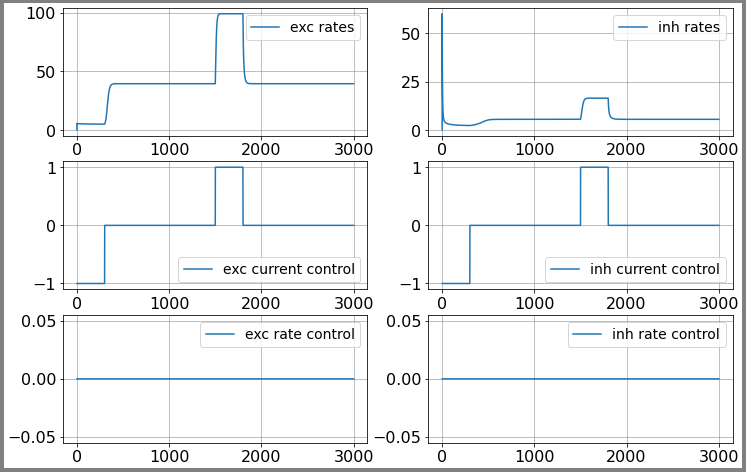

[[38.5063  5.1797]
 [39.4776  5.5185]]


In [572]:
aln = RateModel()

aln.params['duration'] = 3000.

control0 = aln.getZeroControl()
target = aln.getZeroTarget()
control0 = step_control(maxI_ = 1.)

# NO ADAPTATION => else no bistability
aln.params.IA_init = np.array([0.])
aln.params.a = 0.
aln.params.b = 0.

# no noise
aln.params.sigma_ou = 0.

# no delay
aln.params.signalV = 0.
aln.params.de = 0.
aln.params.di = 0.

state = aln.getZeroState()
plotFunc.plot_traces(aln, control0)

output = aln.output_vars

for i in range(len(output)):
    state[:,i,:] = aln[output[i]][:,:]
    
steady_rates = np.zeros((2, 2))
steady_rates[0,0] = np.mean(state[0,0,3000:15000]) # low state exc
steady_rates[0,1] = np.mean(state[0,1,3000:15000]) # low state inh
steady_rates[1,0] = np.mean(state[0,0,19500:]) # high state exc
steady_rates[1,1] = np.mean(state[0,1,19500:]) #high state inh

print(steady_rates)

state_vars = aln.state_vars
init_vars = aln.init_vars

high_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        high_state_vars[i] = aln.state[state_vars[i]][0]
    else:
        high_state_vars[i] = aln.state[state_vars[i]][0,-2]

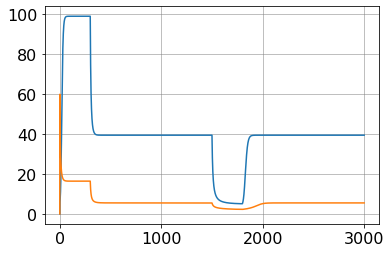

In [573]:
aln.params['duration'] = 3000.
control0 = step_control(maxI_ = -1.)
aln.run(control = control0)
plt.plot(aln.t, aln.rates_exc[0,:])
plt.plot(aln.t, aln.rates_inh[0,:])
plt.show()

low_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        low_state_vars[i] = aln.state[state_vars[i]][0]
    else:
        low_state_vars[i] = aln.state[state_vars[i]][0,-2]

In [574]:
def setinitvars(vars):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,:] = vars[sv]
                else:
                    aln.params[init_vars[iv]][0] = vars[sv]
                    

In [575]:
tol = 1e-18

c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

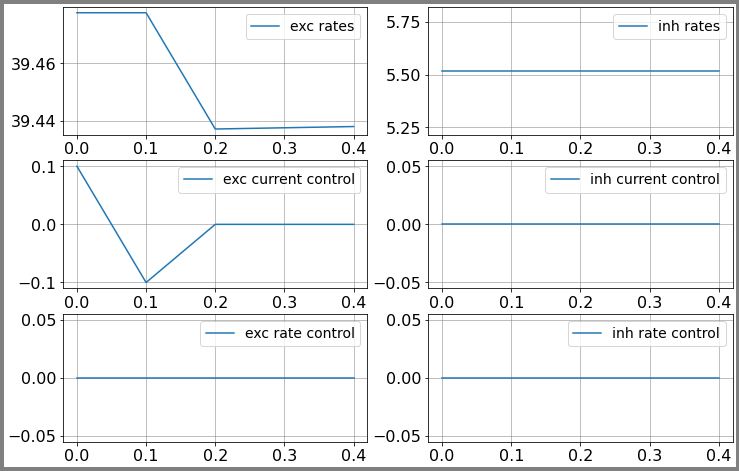

In [576]:
dur = 0.4
dur_pre = 0.
dur_post = 0.
aln.params.duration = dur

control_ind = 0
control0 = aln.getZeroControl()
#control0[0,control_ind,:] = 0.01 * np.sin(np.arange(0,dur+0.1, 0.1))
control0[0,control_ind,0] = 0.1
control0[0,control_ind,1] = -0.1
setinitvars(high_state_vars)

plotFunc.plot_traces(aln, control0)

target = aln.getZeroTarget()
target[0,0,:] = aln.rates_exc[0,:]
target[0,1,:] = aln.rates_inh[0,:]

In [585]:
cost.setParams(1.0, 0., 0.)
max_cntrl = 100. * 5.

setinitvars(high_state_vars)
max_it = 100
start_step = .1
alg = "A1"
case = "test"

aln.params.duration = dur
control1 = aln.getZeroControl()
control2 = bestControlA[:,:,:]
#control2[:,2,2] = - 0.3
control2 = bestControlA_A2[:,:,:]

# "HS", "FR", "PR", "HZ"
cgv = "HSk"

bestControlA, bestStateA, costA, runtimeA, grad = aln.A1(control1, target, c_scheme, u_mat, u_scheme,
        max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
        control_variables_ = [control_ind], prec_variables_ = [0,1])

print("grad = ", grad)

for i in range(1, len(costA)):
    if costA[i-1] < costA[i]:
        print("ERROR ---------------- in index ", i)
        
print("total runtime = ", runtimeA[-1])

set cost params
RUN  0 , total integrated cost =  0.0002386306853548044
No valid variant of conjugate gradient descent selected, use none instead.
RUN  1 , total integrated cost =  1.6417346875400015e-05
RUN  2 , total integrated cost =  7.81918607721713e-06
RUN  3 , total integrated cost =  3.697398422582419e-06
RUN  4 , total integrated cost =  2.0052248319424265e-06
RUN  5 , total integrated cost =  1.1179748445857696e-06
RUN  6 , total integrated cost =  6.152065790753705e-07
RUN  7 , total integrated cost =  3.68747607831749e-07
RUN  8 , total integrated cost =  2.2439479294925707e-07
RUN  9 , total integrated cost =  1.3515974672425772e-07
RUN  10 , total integrated cost =  8.982177843238217e-08
RUN  11 , total integrated cost =  6.096551643326383e-08
RUN  12 , total integrated cost =  3.7029896465851393e-08
RUN  13 , total integrated cost =  2.1627557190385003e-08
RUN  14 , total integrated cost =  1.518549668800394e-08
RUN  15 , total integrated cost =  1.0601344219272507e-08
R

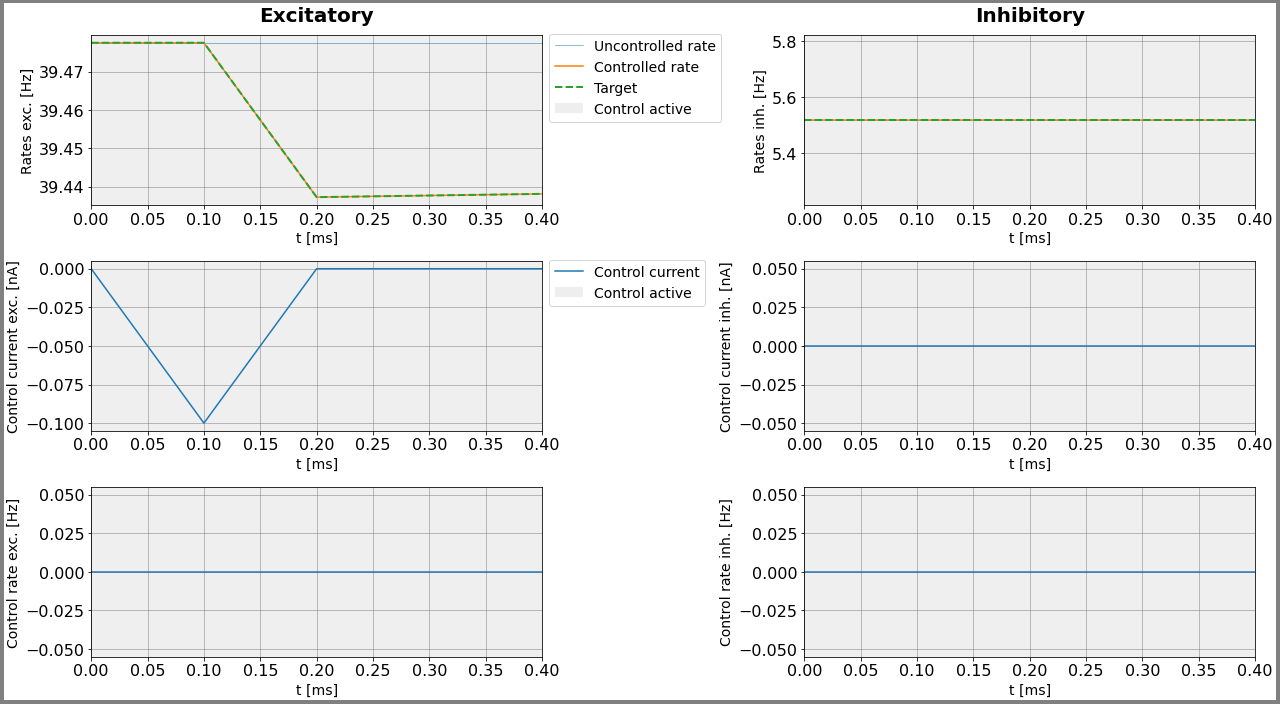

In [584]:
"""
4271381236088862
"""

plotFunc.plot_control(aln, bestControlA, dur, dur_pre, dur_post, high_state_vars, target, path)

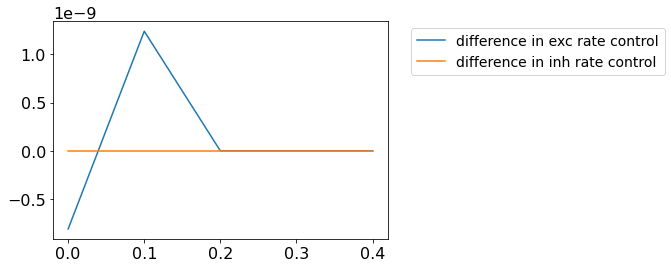

In [515]:
diff = control0 - bestControlA
#diff[0,2,-2:] = 0.

t = np.arange(0,dur+0.1, 0.1)

plt.plot(t, diff[0,2,:], label="difference in exc rate control")
plt.plot(t, diff[0,3,:], label="difference in inh rate control")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.show()

In [536]:
setinitvars(high_state_vars)
max_it = 10
start_step = 10.
alg = "A2"
case = "test"
incl_step = 10
test_step = 1e-8

aln.params.duration = dur
control3 = aln.getZeroControl()
control4 = bestControlA_A2[:,:,:]

bestControlA_A2, bestStateA_A2, costA_A2, runtimeA_A2 = aln.A2(control3, target,
        max_iteration_ = max_it,  tolerance_ = tol, include_timestep_ = incl_step,
        start_step_ = start_step, test_step_ = test_step, max_control_ = max_cntrl,
        t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, control_variables_ = [control_ind])

RUN  0 , total integrated cost:  2.0193477411273323e-05
RUN  1 , total integrated cost:  1.9656630950574166e-05
RUN  2 , total integrated cost:  1.965602481253982e-05
RUN  3 , total integrated cost:  1.965602469710247e-05
RUN  4 , total integrated cost:  1.96560246970844e-05
Control only changes marginally.
RUN  5 , total integrated cost:  1.96560246970844e-05
Improved over  5  iterations by  3  percent.


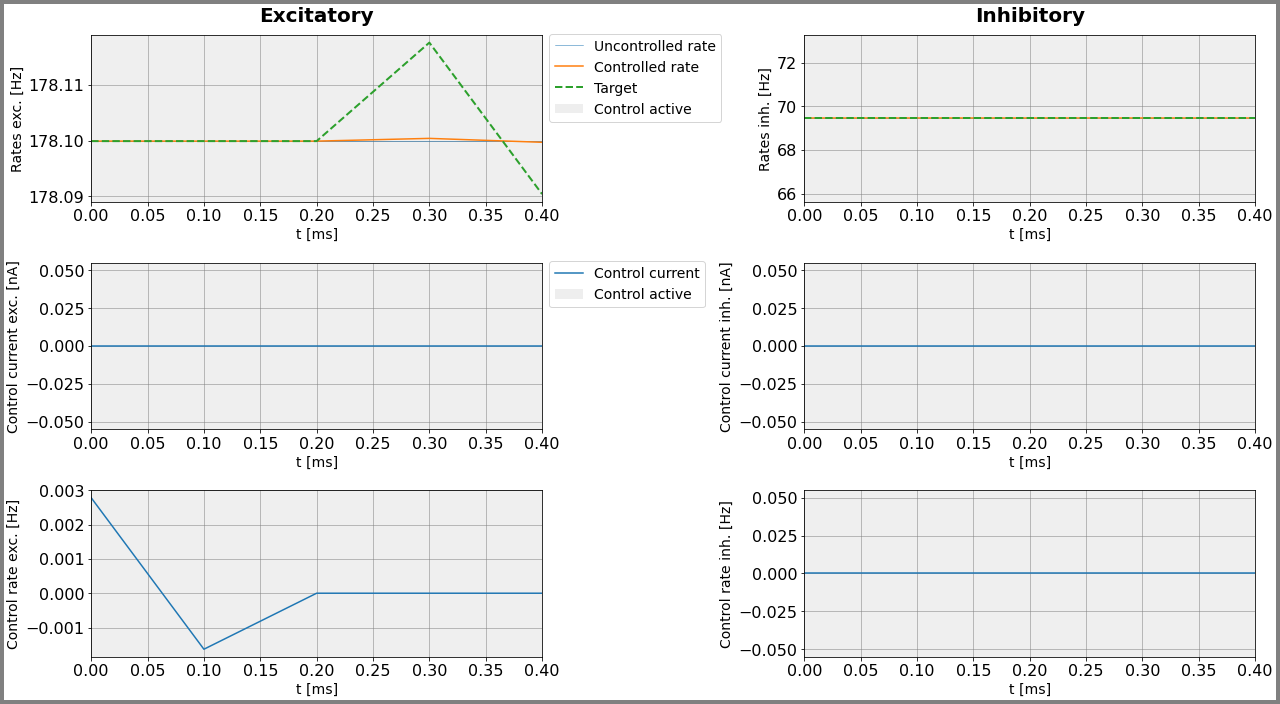

In [537]:
plotFunc.plot_control(aln, bestControlA_A2, dur, dur_pre, dur_post, high_state_vars, target, path)

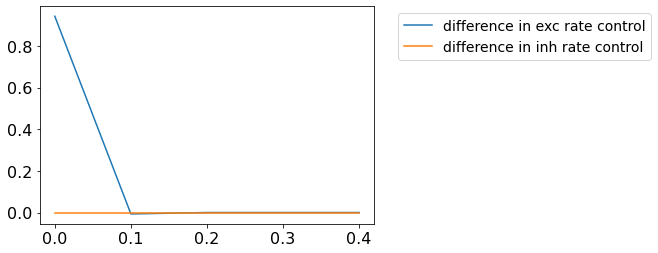

In [433]:
diff = control0 - bestControlA_A2
diff[0,2,-2:] = 0.

t = np.arange(0,dur+0.1, 0.1)

plt.plot(t, diff[0,2,:], label="difference in exc rate control")
plt.plot(t, diff[0,3,:], label="difference in inh rate control")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.show()

-1.96560301164819e-05


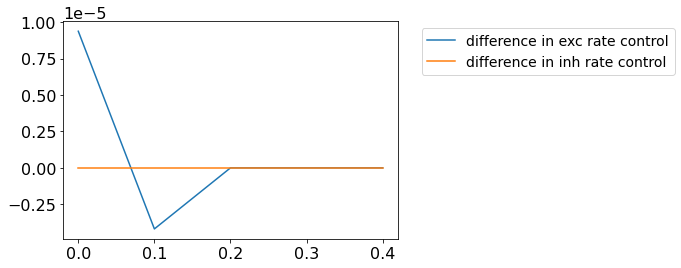

In [542]:
diff = bestControlA - bestControlA_A2
#diff[0,2,-2:] = 0.

c_diff = costA_A2[6] - costA[3]
print(c_diff)

t = np.arange(0,dur+0.1, 0.1)

plt.plot(t, diff[0,2,:], label="difference in exc rate control")
plt.plot(t, diff[0,3,:], label="difference in inh rate control")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.show()